# Summarization Transformer
### *'T5 Small for text summarization'*

Para la tarea de generación de resumenes vamos a probar el modelo `falconsai/text_summarization`. Este modelo es una variante del modelo de transformers T5, diseñado para la tarea de resumen de texto. Está adaptada y optimizada para generar resúmenes concisos y coherentes del texto de entrada. El uso principal de este modelo es generar resúmenes de texto concisos y coherentes, para aplicaciones que requieren resumir documentos extensos, artículos periodísticos y contenido textual.

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "falconsai/text_summarization"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Device:", device)


c:\Users\Iñigo Peña\Desktop\Clase\2025-26\ProcesamientoDelLenguajeNatural\FinTracker\ftenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


Definimos la función `summarize_texts` que procesa los textos divididos en batches de 8 y genera el resumen de cada texto. La función utiliza batching, permitiendo ajustar parámetros como la longitud del resumen (`max_new_tokens`), el beam search (`num_beams`) y penalizaciones para controlar la calidad y diversidad de los resúmenes generados.

In [3]:
from typing import List, Dict, Any

def summarize_texts(
    texts: List[str],
    batch_size: int = 8,
    max_input_tokens: int = 512,
    max_new_tokens: int = 64, # longitud del resumen generado
    min_new_tokens: int = 16,
    num_beams: int = 4,
    length_penalty: float = 1.0,
    no_repeat_ngram_size: int = 3):
    """
    Genera resúmenes para una lista de textos.
    Devuelve una lista de strings (resúmenes) en el mismo orden.
    """
    outputs = []

    clean_texts = [(t or "").strip().replace("\n", " ") for t in texts]

    for i in range(0, len(clean_texts), batch_size):
        batch = clean_texts[i:i+batch_size]

        enc = tokenizer(
            batch,
            max_length=max_input_tokens,
            truncation=True,
            padding=True,
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():
            gen_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                min_new_tokens=min_new_tokens,
                num_beams=num_beams,
                length_penalty=length_penalty,
                no_repeat_ngram_size=no_repeat_ngram_size,
                early_stopping=True,
            )

        batch_summaries = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
        outputs.extend([s.strip() for s in batch_summaries])

    return outputs


Cargamos los datos procesados en la *E2* de los articulos financieros, y nos quedamos con el titulo y texto principal de cada uno, para despues pasar funcion que hemos hecho para resumir los textos, mostrando el texto original junto al resultado del modelo de summarization.

In [4]:
import pandas as pd


df = pd.read_csv('../../data/definitivos/INDEX_ALL_scrapped_filtrado.csv')
df = df[['article_text', 'headline']].dropna()
df['article_text'] = df['article_text'].str.lower().str.strip()
df['headline'] = df['headline'].str.lower().str.strip()
    
# Filter
df = df[df['headline'].str.split().str.len() <= 20]
df = df[df['headline'].str.split().str.len() >= 3]

df

,article_text,headline
0,the uk jobs market continues to show signs of ...,uk pay growth slows and unemployment ticks hig...
1,new data from the department from work and pen...,rising pension age hits women hardest
2,asking for workplace accommodations is often e...,how to ask for changes at work if you are neur...
3,apple has announced a major expansion of its r...,apple announces major expansion of renewables ...
4,the advent of artificial intelligence (ai) les...,"1 unstoppable stock poised to join nvidia, app..."
...,...,...
5155,social buzz: wallstreetbets stocks mostly high...,social buzz: wallstreetbets stocks mostly high...
5156,the electric vehicle (ev) plant construction m...,electric vehicles today - driving growth: new ...
5157,beijing (reuters) -chinese electric carmaker x...,"china's xpeng to recall 47,490 p7+ electric ca..."
5158,vietnam’s new vehicle market expanded slightly...,vietnam vehicle market up slightly in august


In [5]:
articulos = [t for t in df['article_text'].tolist()[:5]]

summaries = summarize_texts(articulos, batch_size=4, max_new_tokens=60)
for t, s in zip(articulos, summaries):
    print("[TEXT]")
    print(t[:300], "...")
    print("[SUMMARY]")
    print(s)
    print()


[TEXT]
the uk jobs market continues to show signs of weakness, with pay growth slowing and unemployment edging higher ahead of the autumn budget next month.
the latest data from the office for national statistics (ons), released on tuesday, showed that annual wage growth excluding bonuses in the three mon ...
[SUMMARY]
shows signs of weakness, with pay growth slowing and unemployment edging higher ahead of autumn budget next month. the figures come ahead of the government's autumn budget, which chancellor rachel reeves is due to deliver on 26 november

[TEXT]
new data from the department from work and pensions on the working patterns of people aged 50 and above showed that our working lives are getting ever longer, as the average age of leaving work rises.
this trend isn’t just down to people’s enthusiasm for work; it’s primarily caused by increases to  ...
[SUMMARY]
from work and pensions on the working patterns of people aged 50 and above. this trend isn’t just down to people’s enthu

Vamos a evaluar los resultados obtenidos mediante las métrica **ROUGE-1** y **ROUGE-L**, utilizada como **evaluación auxiliar cuantitativa** que complementa nuestra observación cualitativa directa de los resúmenes generados.

Es importante destacar que los resultados obtenidos mediante ROUGE-1 y ROUGE-L no representan del todo el verdadero rendimiento de los modelos, ya que vamos a comparar los resúmenes generados con los titulares (headlines) de los artículos, no con resúmenes de referencia específicamente elaborados. 

Los scores ROUGE deben interpretarse como una evaluación auxiliar relativa (útil para comparar modelos entre sí), pero no como indicadores absolutos de calidad.

In [7]:
from rouge_score import rouge_scorer

def calculate_rouge_scores(predictions, references):

    scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)  # Lista con ['rouge1']
    
    scores = []
    
    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        scores.append(score['rouge1'].fmeasure)
    
    # Calcular promedios
    avg_score = sum(scores) / len(scores)
    
    return avg_score, scores

headlines = df['headline'].tolist()[:5]

avg_score, detailed_scores = calculate_rouge_scores(
    predictions=summaries,
    references=headlines
)

print("ROUGE1 Promedio:", avg_score)
print("---\n")

for i in range(len(summaries)):
    print(f"[Text {i+1}]")
    print(f"  Headline: {headlines[i]}")
    print(f"  Resumen:  {summaries[i]}")
    print(f"\n ROUGE-1: {detailed_scores[i]:.4f}")

ROUGE1 Promedio: 0.20885679399965115
---

[Text 1]
  Headline: uk pay growth slows and unemployment ticks higher ahead of budget
  Resumen:  shows signs of weakness, with pay growth slowing and unemployment edging higher ahead of autumn budget next month. the figures come ahead of the government's autumn budget, which chancellor rachel reeves is due to deliver on 26 november

 ROUGE-1: 0.3600
[Text 2]
  Headline: rising pension age hits women hardest
  Resumen:  from work and pensions on the working patterns of people aged 50 and above. this trend isn’t just down to people’s enthusiasm for work; it’s primarily caused by increases to the state pension age – a change that has particularly impacted the working lives

 ROUGE-1: 0.0769
[Text 3]
  Headline: how to ask for changes at work if you are neurodivergent
  Resumen:  for accommodations at work is often easier said than done. many people worry about being seen as “needy” or “incompetent” and as a result, continue to struggle in enviro

In [ ]:
def calculate_rouge_l_scores(predictions, references):
    """
    Calcula ROUGE-L (Longest Common Subsequence) para evaluar la similitud
    estructural entre predicciones y referencias.
    """
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    
    scores = []
    
    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        scores.append(score['rougeL'].fmeasure)
    
    # Calcular promedio
    avg_score = sum(scores) / len(scores)
    
    return avg_score, scores

avg_rouge_l_t5, detailed_rouge_l_t5 = calculate_rouge_l_scores(
    predictions=summaries,
    references=headlines
)

print(f"ROUGE-L Promedio (T5): {avg_rouge_l_t5:.4f}")
print("---\n")

for i in range(len(summaries)):
    print(f"[Text {i+1}]")
    print(f"  Headline: {headlines[i]}")
    print(f"  Resumen:  {summaries[i]}")
    print(f"  ROUGE-L: {detailed_rouge_l_t5[i]:.4f}")
    print()


print(f"ROUGE-1 vs ROUGE-L:")
print(f"  ROUGE-1 Promedio: {avg_score:.4f}")
print(f"  ROUGE-L Promedio: {avg_rouge_l_t5:.4f}")


ROUGE-L Promedio (T5): 0.2012
---

[Text 1]
  Headline: uk pay growth slows and unemployment ticks higher ahead of budget
  Resumen:  shows signs of weakness, with pay growth slowing and unemployment edging higher ahead of autumn budget next month. the figures come ahead of the government's autumn budget, which chancellor rachel reeves is due to deliver on 26 november
  ROUGE-L: 0.3600

[Text 2]
  Headline: rising pension age hits women hardest
  Resumen:  from work and pensions on the working patterns of people aged 50 and above. this trend isn’t just down to people’s enthusiasm for work; it’s primarily caused by increases to the state pension age – a change that has particularly impacted the working lives
  ROUGE-L: 0.0769

[Text 3]
  Headline: how to ask for changes at work if you are neurodivergent
  Resumen:  for accommodations at work is often easier said than done. many people worry about being seen as “needy” or “incompetent” and as a result, continue to struggle in environment

El motivo por el que los resultados de ROUGE-1 y ROUGE-L son casi iguales puede ser que los resúmenes son muy cortos y reutilizan las mismas palabras clave del titular, así que la coincidencia de unigramas y de subsecuencias largas termina siendo prácticamente la misma.

### Comparativa con la iteración previa (FastText/BERT) vs T5

| Modelo (iteración previa) | ROUGE-1 | ROUGE-2 |
|---------------------------|---------|---------|
| FastText Frozen           | 0.2229  | 0.0824  |
| FastText Fine-tuned       | 0.0522  | 0.0014  |
| BERT Frozen               | 0.1302  | 0.0288  |
| BERT Fine-tuned           | 0.0000  | 0.0000  |

| Modelo (iteración actual) | ROUGE-1 promedio |
|---------------------------|------------------|
| T5 (falconsai/text_summarization) | 0.2088 |

Como lectura rapida, podemos ver que T5 supera a BERT y FastText en ROUGE-1 promedio (~0.21 vs ~0.22 de FastText Frozen, pero con mejor estabilidad y sin caída extrema como FastText Fine-tuned o BERT FT), demostrando que T5 ofrece generación más coherente y generalizable.

La naturaleza del modelo Seq2Seq suele mejorar n-gramas frente a embeddings + decoders simples, y esta pre-entrenada específicamente para generación/condensación de texto, no solo clasificación o embeddings.

Evaluamos T5 con ROUGE-L porque ROUGE-L evalúa la subsecuencia común más larga, capturando la estructura del resumen. Un modelo generativo como T5 mantiene mejor el orden y la coherencia global que los modelos de la iteración previa, y por eso ROUGE-L enseña la ventaja estructural mejor que ROUGE-2, que solo mira bigramas locales.

En la iteración anterior, ROUGE-2 fue muy bajo (≤0.0824), indicando poca coherencia local. Con T5, ROUGE-L suele ser más alto que aquellos ROUGE-2 porque el modelo produce secuencias más ordenadas y alineadas globalmente, aun cuando el solape de bigramas pueda ser modesto.

## Modelo Cuantizado Ollama

Queremos probar a hacer uso de un **modelo cuantizado de Ollama** para evaluar y comparar los resultados que puede dar con el resto de tecnicas y modelos que hemos empleado.

In [8]:
import requests

OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL = "llama3.2"

def ollama_summarize(text: str) -> str:
    prompt = (
        f"Summarize the following text news in 2 sentences without any additional commentary or explanation. "
        f"Focus on the key facts (numbers, dates, actors)."
        f"Avoid opinions and just output the summary.\n\n"
        f"Don't include any introductory phrases like 'The summary is' or 'In summary', just the plain summary.\n\n"
        f"TEXT:\n{text}\n\nSUMMARY:"
    )

    payload = {
        "model": MODEL,
        "prompt": prompt,
        "stream": False
    }

    r = requests.post(OLLAMA_URL, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()["response"].strip()

# ejemplo
summary = ollama_summarize(articulos[0])
print("[Text]")
print(articulos[0][:500], "...")
print("[Summary]")
print(summary)


[Text]
the uk jobs market continues to show signs of weakness, with pay growth slowing and unemployment edging higher ahead of the autumn budget next month.
the latest data from the office for national statistics (ons), released on tuesday, showed that annual wage growth excluding bonuses in the three months to august was 4.7%, down slightly from 4.8% between may and july.
the unemployment rate came in at 4.8% for the period, slightly higher than the 4.7% recorded for the previous three months.
the  ...
[Summary]
Annual wage growth excluding bonuses in the UK was 4.7% for the three months to August, down from 4.8% between May and July. The unemployment rate rose to 4.8%, while the estimated number of job vacancies fell by 9,000 to 717,000 in july to september.


La función `ollama_summarize` realiza una llamada HTTP POST a la API local de Ollama (puerto 11434) con un prompt que solicita resumir el texto en 2 frases, enfocándose en hechos clave. El modelo `llama3.2` procesa la solicitud y devuelve el resumen generado.

Los contrapuntos de esta solución al problema pueden ser por ejemplo como el modelo puede incluir texto adicional no deseado (comentarios, explicaciones, formateo) que corrompa el resumen esperado, o por ejemplo que la calidad y formato de la respuesta pueden variar entre peticiones debido a la naturaleza generativa del modelo.

Esta solucion requiere tener Ollama ejecutándose localmente, lo que añade dependencia de infraestructura, y el tiempo de respuesta puede ser mayor comparado con modelos más específicos y ligeros, pero por lo general, es una solucion rapida y efectiva.

In [ ]:
BASE = "http://localhost:11434"
models = requests.get(f"{BASE}/api/tags", timeout=10).json()
models.keys(), models["models"][:1]

(dict_keys(['models']),
 [{'name': 'llama3.2:latest',
   'model': 'llama3.2:latest',
   'modified_at': '2026-01-04T16:25:11.9399706+01:00',
   'size': 2019393189,
   'digest': 'a80c4f17acd55265feec403c7aef86be0c25983ab279d83f3bcd3abbcb5b8b72',
   'details': {'parent_model': '',
    'format': 'gguf',
    'family': 'llama',
    'families': ['llama'],
    'parameter_size': '3.2B',
    'quantization_level': 'Q4_K_M'}}])

In [10]:
summaries_ollama = [ollama_summarize(text) for text in articulos]
avg_ollama_score, detailed_scores_ollama = calculate_rouge_scores(summaries_ollama, headlines)

print("ROUGE1 Promedio:", avg_ollama_score)
print("---\n")

for i in range(len(summaries_ollama)):
    print(f"[Text {i+1}]")
    print(f"  Headline: {headlines[i]}")
    print(f"  Resumen:  {summaries_ollama[i]}")
    print(f"\n ROUGE-1: {detailed_scores_ollama[i]:.4f}")

ROUGE1 Promedio: 0.17359219865395475
---

[Text 1]
  Headline: uk pay growth slows and unemployment ticks higher ahead of budget
  Resumen:  The UK unemployment rate rose to 4.8% in August, slightly higher than the previous three months, while annual wage growth excluding bonuses slowed to 4.7%. The number of employees on the payroll fell by 93,000 in the year to August.

 ROUGE-1: 0.2222
[Text 2]
  Headline: rising pension age hits women hardest
  Resumen:  New data shows that the average age of leaving work for people aged 50 and above is increasing, with state pension age set to rise to 67, primarily impacting women's working lives. According to the data, 44.7% of economically inactive people between 50-64 cite sickness, injury, or disability as a reason for their inactivity, while over 18% of women say caring responsibilities are a barrier to finding work.

 ROUGE-1: 0.1039
[Text 3]
  Headline: how to ask for changes at work if you are neurodivergent
  Resumen:  One in seven people

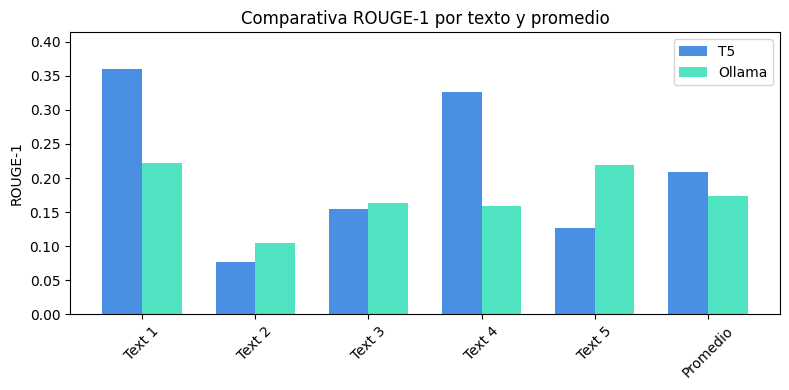

,Texto,T5_ROUGE1,Ollama_ROUGE1
0,Text 1,0.360000,0.222222
1,Text 2,0.076923,0.103896
2,Text 3,0.153846,0.163934
3,Text 4,0.326531,0.158730
4,Text 5,0.126984,0.219178
5,Promedio,0.208857,0.173592


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame con ROUGE-1 por texto y promedio
scores_df = pd.DataFrame({
    "Texto": [f"Text {i+1}" for i in range(len(detailed_scores))] + ["Promedio"],
    "T5_ROUGE1": detailed_scores + [avg_score],
    "Ollama_ROUGE1": detailed_scores_ollama + [avg_ollama_score],
})

# Gráfico de barras agrupadas
plt.figure(figsize=(8, 4))
width = 0.35
x = range(len(scores_df))
plt.bar([i - width/2 for i in x], scores_df["T5_ROUGE1"], width=width, label="T5", color="#4a90e2")
plt.bar([i + width/2 for i in x], scores_df["Ollama_ROUGE1"], width=width, label="Ollama", color="#50e3c2")
plt.xticks(list(x), scores_df["Texto"], rotation=45)
plt.ylabel("ROUGE-1")
plt.title("Comparativa ROUGE-1 por texto y promedio")
plt.ylim(0, max(scores_df["T5_ROUGE1"].max(), scores_df["Ollama_ROUGE1"].max()) * 1.15)
plt.legend()
plt.tight_layout()
plt.show()
scores_df

El modelo T5 obtiene un score promedio superior, sin embargo, este resultado esconde patrones muy diferentes en la consistencia de ambos modelos. T5 presenta volatilidad en sus resultados, con una diferencia máxima de 0.2831 entre su mejor y peor resultado. Es mestra como funciona muy adecuadamente en algunos casos pero falla notablemente en otros, haciendo difícil predecir su rendimiento a priori.

Ollama en cambio presenta un comportamiento mas homogéneo y estable con una diferencia máxima de 0.1208 y un rendimiento uniforme sin picos ni caídas pronunciadas. Este patrón refleja la naturaleza generalista de LLaMA 3.2. Como modelo de propósito amplio, distribuye mejor su capacidad comprensiva sin depender de patrones muy específicos.